<a href="https://colab.research.google.com/github/huyle31251027190/BTVN-AI/blob/main/BTVN_AI_25_5_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install mtcnn opencv-python tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.6 MB/s eta 0:00:00


KẾT QUẢ NHẬN DIỆN
Người dự đoán: Lê Minh Huy
Độ tin cậy: 100.0 %


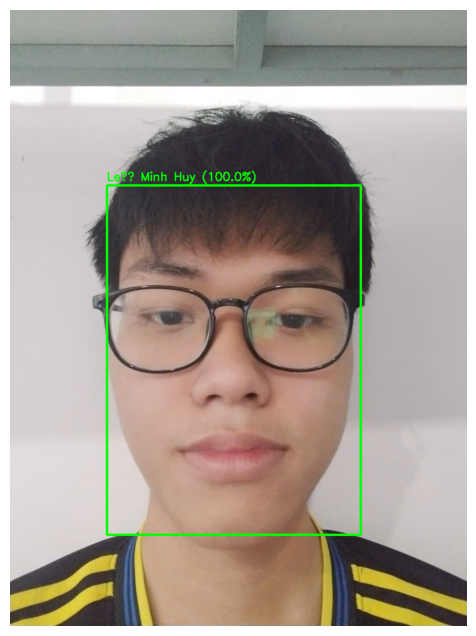

In [9]:
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt

from mtcnn import MTCNN
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array


MODEL_PATH = "/content/face_recognition_cnn.h5"
LABEL_PATH = "/content/memberclass_cnn.json"
IMAGE_PATH = "/content/z7876296125678_7fea52332e11ae5b8de1ee2387a29ad9.jpg"
TARGET_SIZE = (160, 160)


def load_class_labels(label_path):
    with open(label_path, "r") as f:
        class_indices = json.load(f)
    return {v: k for k, v in class_indices.items()}


def preprocess_face(face_img):
    face_img = cv2.resize(face_img, TARGET_SIZE)
    face_img = face_img.astype("float32") / 255.0
    face_img = img_to_array(face_img)
    face_img = np.expand_dims(face_img, axis=0)
    return face_img


def main():
    model = load_model(MODEL_PATH)
    labels = load_class_labels(LABEL_PATH)
    detector = MTCNN()

    image = cv2.imread(IMAGE_PATH)
    if image is None:
        raise FileNotFoundError("Không đọc được ảnh!")

    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    faces = detector.detect_faces(rgb_image)

    if not faces:
        print("Không phát hiện khuôn mặt!")
        return

    x, y, w, h = faces[0]["box"]
    x = max(0, x)
    y = max(0, y)

    face = rgb_image[y:y + h, x:x + w]
    if face.size == 0:
        print("Không cắt được khuôn mặt hợp lệ!")
        return

    face_input = preprocess_face(face)
    prediction = model.predict(face_input, verbose=0)

    predicted_class = int(np.argmax(prediction))
    confidence = float(np.max(prediction))
    person_name = labels[predicted_class]

    print("======================================")
    print("KẾT QUẢ NHẬN DIỆN")
    print("======================================")
    print("Người dự đoán:", person_name)
    print("Độ tin cậy:", round(confidence * 100, 2), "%")

    cv2.rectangle(rgb_image, (x, y), (x + w, y + h), (0, 255, 0), 3)
    cv2.putText(
        rgb_image,
        f"{person_name} ({round(confidence * 100, 2)}%)",
        (x, max(0, y - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(rgb_image)
    plt.axis("off")
    plt.show()


if __name__ == "__main__":
    main()